# Criando dataset para calcular as  faltas injustificadas X CLT:


In [59]:
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px
import itertools

df_deputados = pd.read_json('../../data/processed/deputados.json') 
df_eventos = pd.read_csv('../../data/processed/eventos.csv')
df_presencas = pd.read_csv('../../data/processed/presencas.csv')
votacoes_all = pd.read_csv("../../data/processed/votacoes_2020-02_2025-10_todas.csv")

## 3. Faltas injustificadas vs limite CLT

In [71]:
# Eventos do tipo Sessão Deliberativa
df_sessoes = (
    df_eventos
    .loc[df_eventos["descricaoTipo"].eq("Sessão Deliberativa"), ["id"]]
    .rename(columns={"id": "id_evento"})
)

# garantir tipos numéricos compatíveis
df_sessoes["id_evento"] = pd.to_numeric(df_sessoes["id_evento"], errors="coerce")
df_presencas["id_evento"] = pd.to_numeric(df_presencas["id_evento"], errors="coerce")

df_sessoes.head()

df_presencas.head()

,id_evento,id_deputado,ano_origem
0,58552,69871,2020
1,58552,73466,2020
2,58552,73696,2020
3,58552,74057,2020
4,58552,74200,2020


In [73]:
df_pres_sessoes = (
    df_presencas[
        df_presencas["id_evento"].isin(df_sessoes["id_evento"])
    ][["id_evento", "id_deputado"]]
    .dropna()
    .drop_duplicates()
)

df_pres_sessoes

,id_evento,id_deputado
249,59265,66179
250,59265,66828
251,59265,67138
252,59265,68720
253,59265,69871
...,...,...
557755,79645,231911
557756,79645,233218
557757,79645,233592
557758,79645,233594


In [74]:
# 3) Universo de deputados a considerar
#    (apenas quem aparece em presenças)
deputados_ids = (
    df_pres_sessoes["id_deputado"]
    .dropna()
    .unique()
)

deputados_ids

array([ 66179,  66828,  67138,  68720,  69871,  72442,  73433,  73441,
        73460,  73466,  73482,  73486,  73531,  73586,  73604,  73696,
        73701,  73772,  73788,  73801,  73808,  73891,  73943,  74043,
        74052,  74057,  74060,  74075,  74079,  74156,  74158,  74159,
        74160,  74161,  74200,  74262,  74270,  74283,  74299,  74305,
        74317,  74319,  74352,  74356,  74366,  74371,  74376,  74383,
        74398,  74400,  74439,  74459,  74467,  74471,  74478,  74537,
        74554,  74574,  74585,  74646,  74655,  74693,  74749,  74784,
        74848,  75431,  76874,  81055,  81297,  90201,  90842,  92102,
        92346,  92699,  92776,  93083,  98057, 108338, 109429, 115746,
       116379, 121948, 122158, 122466, 122974, 132504, 133439, 133810,
       133968, 134812, 135054, 136811, 139285, 141335, 141391, 141398,
       141401, 141405, 141411, 141417, 141421, 141422, 141427, 141428,
       141431, 141434, 141439, 141450, 141459, 141470, 141488, 141508,
      

In [79]:
# 4) Todas as combinações (sessão, deputado)
#    -> "deveria estar presente"

df_expect = pd.DataFrame(
    itertools.product(df_sessoes["id_evento"].unique(), deputados_ids),
    columns=["id_evento", "id_deputado"]
)

df_expect

,id_evento,id_deputado
0,59265,66179
1,59265,66828
2,59265,67138
3,59265,68720
4,59265,69871
...,...,...
352011,79645,233218
352012,79645,141533
352013,79645,233592
352014,79645,233594


In [80]:
# 5) Marcar quem estava presente
df_expect = df_expect.merge(
    df_pres_sessoes.assign(presente=1),
    on=["id_evento", "id_deputado"],
    how="left"
)

df_expect["presente"] = df_expect["presente"].fillna(0).astype(int)

df_expect

,id_evento,id_deputado,presente
0,59265,66179,1
1,59265,66828,1
2,59265,67138,1
3,59265,68720,1
4,59265,69871,1
...,...,...,...
352011,79645,233218,1
352012,79645,141533,1
352013,79645,233592,1
352014,79645,233594,1


In [81]:
# 6) Falta (tratando toda ausência como injustificada por enquanto)

df_expect["faltas_injustificadas"] = np.where(
    df_expect["presente"] == 0, 1, 0
)

df_faltas_dep = (
    df_expect
    .groupby("id_deputado", as_index=False)["faltas_injustificadas"]
    .sum()
)

df_faltas_dep

,id_deputado,faltas_injustificadas
0,62881,126
1,66179,171
2,66385,272
3,66828,63
4,67138,195
...,...,...
893,231911,365
894,233218,383
895,233592,384
896,233594,384


In [87]:
# ponto de partida: catálogo de deputados
df_dep = (
    df_deputados
    .rename(columns={"id": "id_deputado"})
    [["id_deputado", "nome"]]                 # pega só o essencial por enquanto
    .merge(df_faltas_dep, on="id_deputado", how="left")
)

df_dep["faltas_injustificadas"] = (
    df_dep["faltas_injustificadas"]
    .fillna(0)
    .astype(int)
)

# se quiser, já renomeia para bater com o gráfico:
df_dep = df_dep.rename(columns={"nome": "deputado"})

df_dep

,id_deputado,deputado,faltas_injustificadas
0,204379,Acácio Favacho,91
1,220714,Adail Filho,274
2,221328,Adilson Barroso,276
3,204560,Adolfo Viana,87
4,204528,Adriana Ventura,42
...,...,...,...
508,220558,Zé Trovão,272
509,204517,Zé Vitor,69
510,160592,Zeca Dirceu,56
511,220592,Zezinho Barbary,282


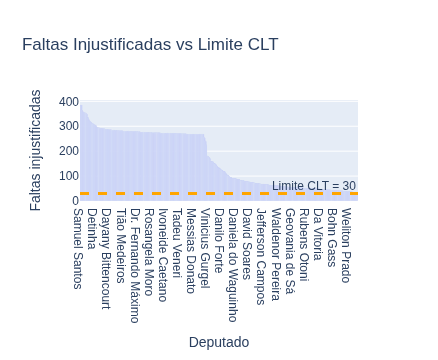

In [89]:
palette_main = "#ff7f0e"

limite_faltas_clt = 30  # ou o valor que você está usando

df_plot3 = df_dep.sort_values("faltas_injustificadas", ascending=False)

fig3 = px.bar(
    df_plot3,
    x="deputado",
    y="faltas_injustificadas",
    labels={
        "faltas_injustificadas": "Faltas injustificadas",
        "deputado": "Deputado",
    },
    title="Faltas Injustificadas vs Limite CLT",
)

fig3.add_hline(
    y=limite_faltas_clt,
    line_dash="dash",
    line_width=3,
    line_color="orange",
    annotation_text=f"Limite CLT = {limite_faltas_clt}",
    annotation_position="top right",
)

fig3.show()

In [90]:
df_dep.to_csv("../../data/graphs/df_dep_injustificado.csv", index=False)
